In [9]:
2+2

4

In [10]:
import pandas as pd

In [11]:
df=pd.read_excel("Dataset/Pokemon.xlsx")
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,Ninguno,309,39,52,43,60,50,65,1,False


In [12]:
df["Total"].mean()

np.float64(435.1025)

In [13]:
import pandas as pd; import openpyxl; print('pandas', pd.__version__); import os; print('cwd', os.getcwd()); df=pd.read_excel('Dataset/Pokemon.xlsx'); print('shape', df.shape); print('columns', list(df.columns)); print(df.head().to_string())

pandas 3.0.3
cwd c:\Users\Guillermo\OneDrive\Escritorio\Repositorio\Prueba_proyecto-1
shape (800, 13)
columns ['#', 'Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary']
   #                   Name Type 1   Type 2  Total  HP  Attack  Defense  Sp. Atk  Sp. Def  Speed  Generation  Legendary
0  1              Bulbasaur  Grass   Poison    318  45      49       49       65       65     45           1      False
1  2                Ivysaur  Grass   Poison    405  60      62       63       80       80     60           1      False
2  3               Venusaur  Grass   Poison    525  80      82       83      100      100     80           1      False
3  3  VenusaurMega Venusaur  Grass   Poison    625  80     100      123      122      120     80           1      False
4  4             Charmander   Fire  Ninguno    309  39      52       43       60       50     65           1      False


In [14]:
# Análisis descriptivo del dataset
print('Forma del dataset:', df.shape)
print('\nTipos de datos:\n', df.dtypes.to_string())
print('\nResumen estadístico general:\n')
print(df.describe(include='all').T.to_string())

# Estadísticas clave para variables numéricas
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
print('\nVariables numéricas:', numeric_cols)
print('\nPromedios por variable numérica:\n')
print(df[numeric_cols].mean().to_string())

# Conteo de tipos por generación (si existe)
if 'Generation' in df.columns:
    print('\nConteo por generación:\n')
    print(df['Generation'].value_counts().sort_index().to_string())


Forma del dataset: (800, 13)

Tipos de datos:
 #             int64
Name            str
Type 1          str
Type 2          str
Total         int64
HP            int64
Attack        int64
Defense       int64
Sp. Atk       int64
Sp. Def       int64
Speed         int64
Generation    int64
Legendary      bool

Resumen estadístico general:

            count unique        top freq       mean         std    min     25%    50%     75%    max
#           800.0    NaN        NaN  NaN  362.81375  208.343798    1.0  184.75  364.5  539.25  721.0
Name          800    800  Bulbasaur    1        NaN         NaN    NaN     NaN    NaN     NaN    NaN
Type 1        800     18      Water  112        NaN         NaN    NaN     NaN    NaN     NaN    NaN
Type 2        800     19    Ninguno  386        NaN         NaN    NaN     NaN    NaN     NaN    NaN
Total       800.0    NaN        NaN  NaN   435.1025   119.96304  180.0   330.0  450.0   515.0  780.0
HP          800.0    NaN        NaN  NaN   69.25875   25

Matriz de correlaciones:

               #  Total    HP  Attack  Defense  Sp. Atk  Sp. Def  Speed  Generation
#           1.00   0.12  0.10    0.10     0.09     0.09     0.09   0.01        0.98
Total       0.12   1.00  0.62    0.74     0.61     0.75     0.72   0.58        0.05
HP          0.10   0.62  1.00    0.42     0.24     0.36     0.38   0.18        0.06
Attack      0.10   0.74  0.42    1.00     0.44     0.40     0.26   0.38        0.05
Defense     0.09   0.61  0.24    0.44     1.00     0.22     0.51   0.02        0.04
Sp. Atk     0.09   0.75  0.36    0.40     0.22     1.00     0.51   0.47        0.04
Sp. Def     0.09   0.72  0.38    0.26     0.51     0.51     1.00   0.26        0.03
Speed       0.01   0.58  0.18    0.38     0.02     0.47     0.26   1.00       -0.02
Generation  0.98   0.05  0.06    0.05     0.04     0.04     0.03  -0.02        1.00


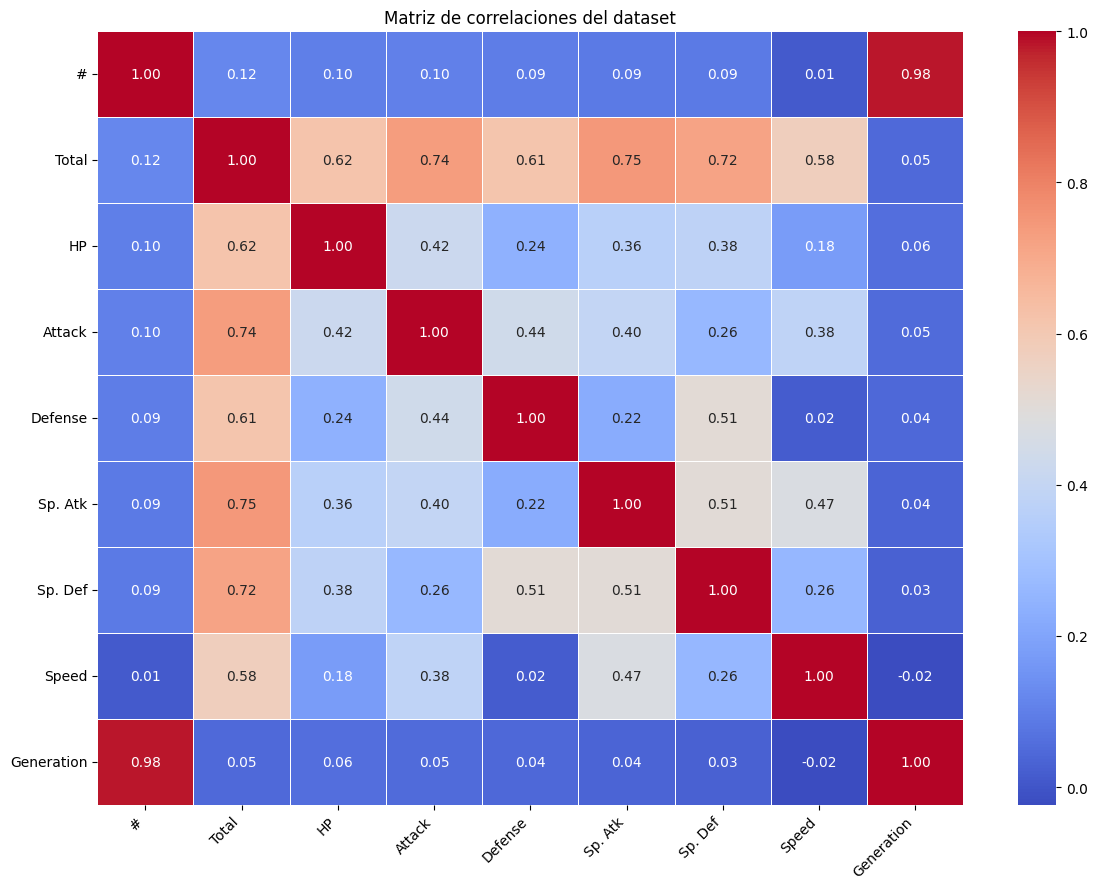

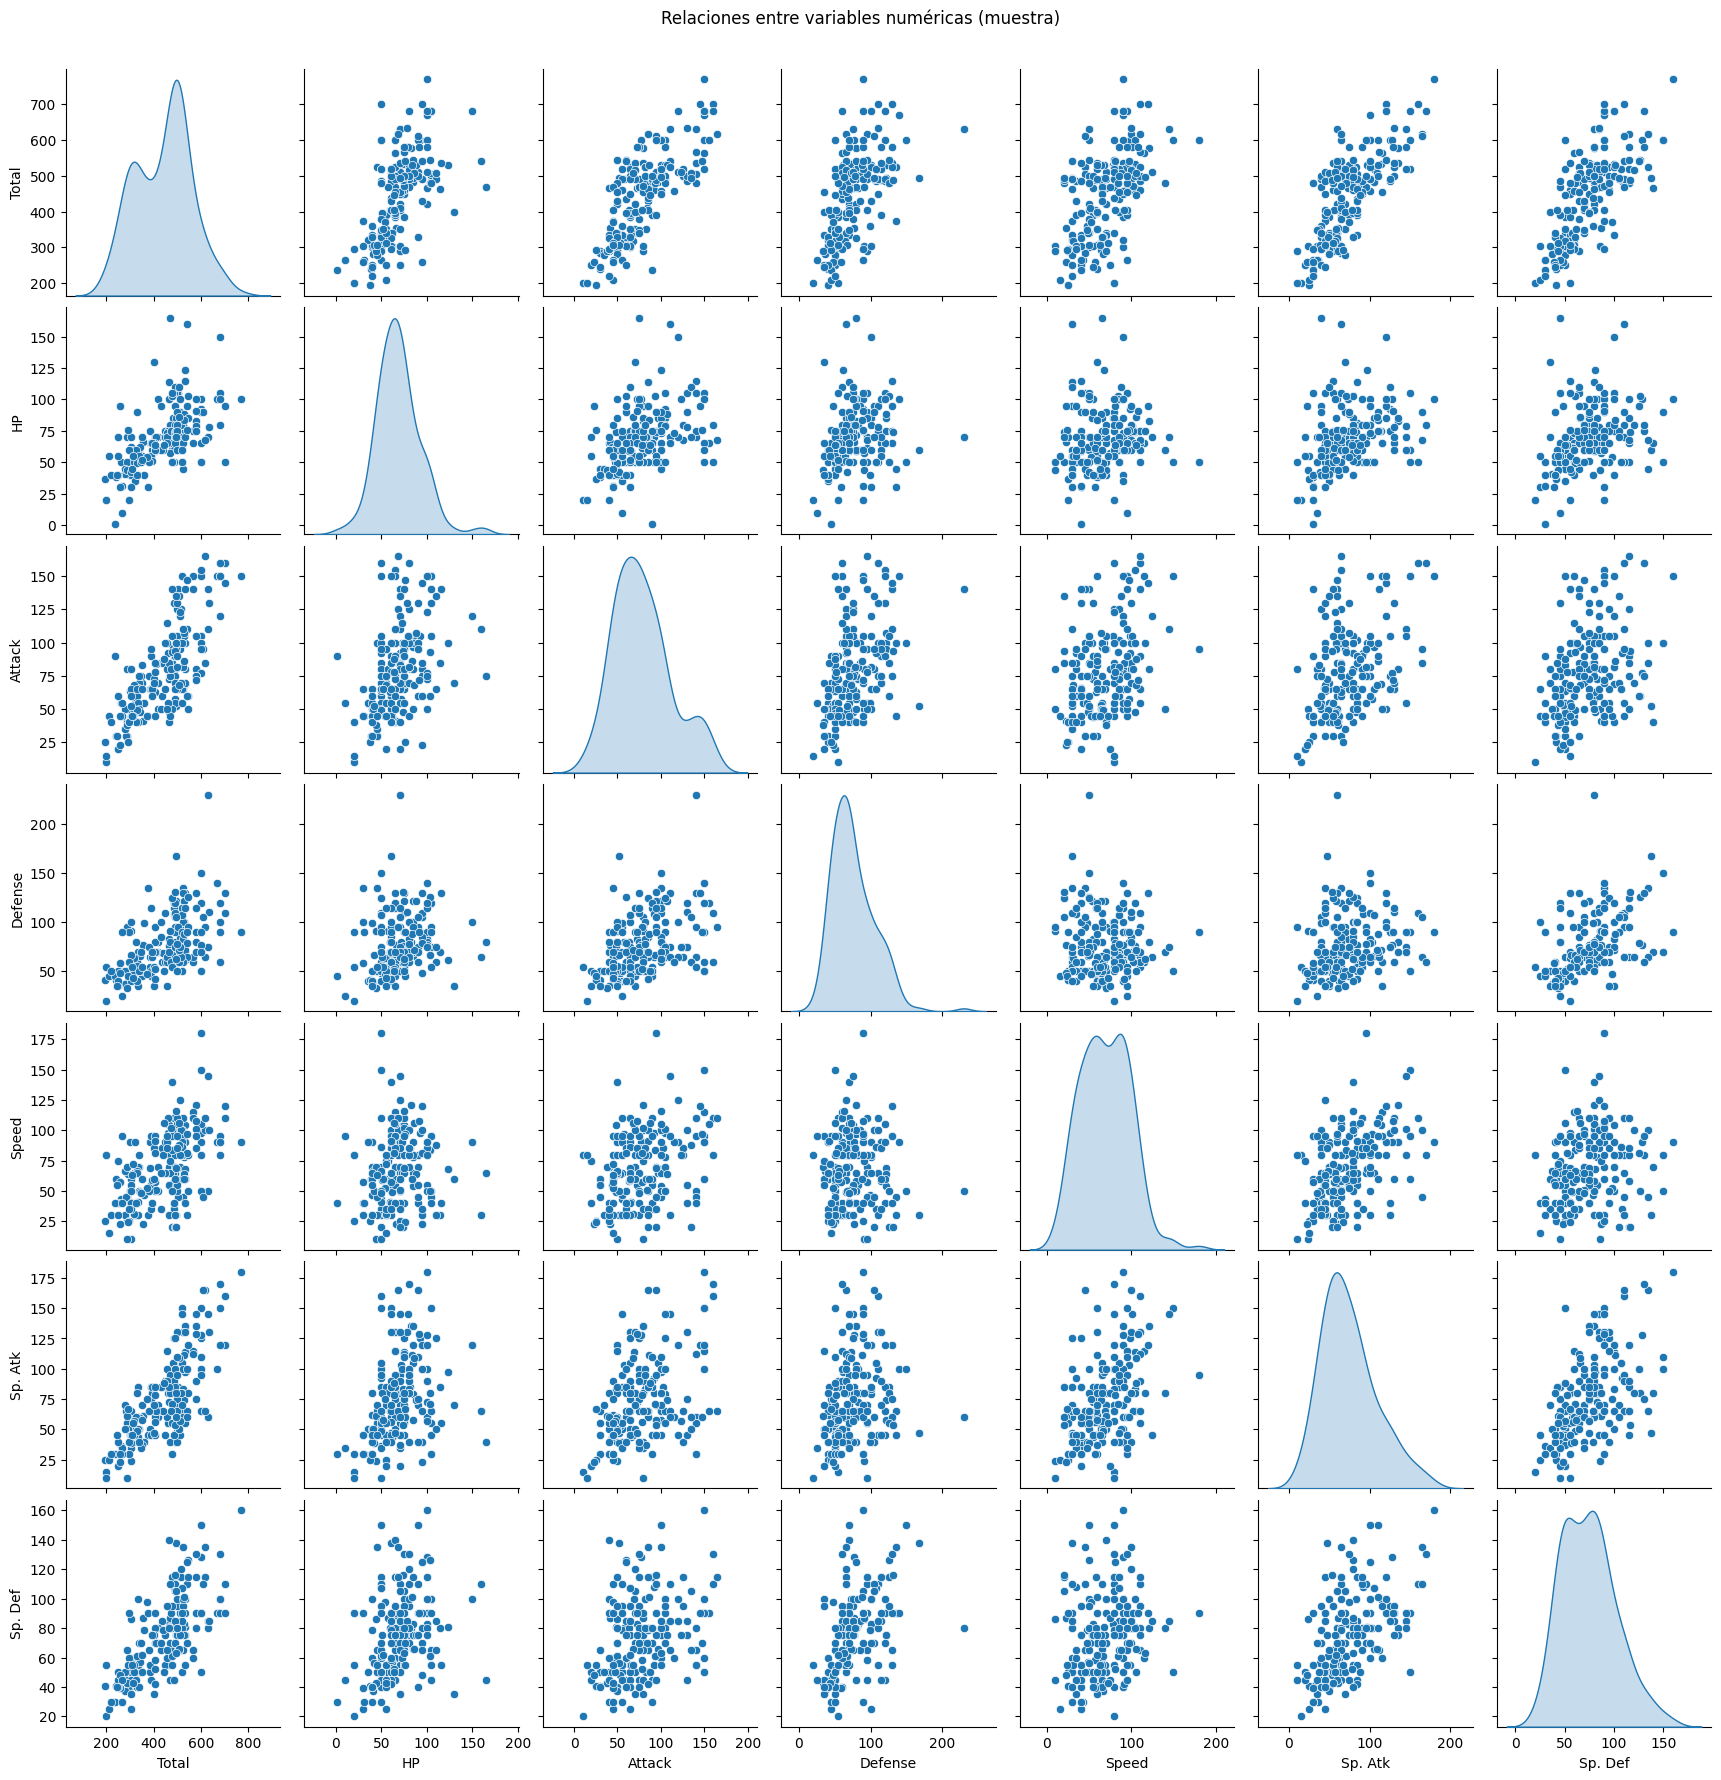

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()
print('Matriz de correlaciones:\n')
print(corr.round(2).to_string())

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de correlaciones del dataset')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

sample_df = numeric_df[['Total', 'HP', 'Attack', 'Defense', 'Speed', 'Sp. Atk', 'Sp. Def']].sample(200, random_state=42)
sns.pairplot(sample_df, diag_kind='kde')
plt.suptitle('Relaciones entre variables numéricas (muestra)', y=1.02)
plt.show()

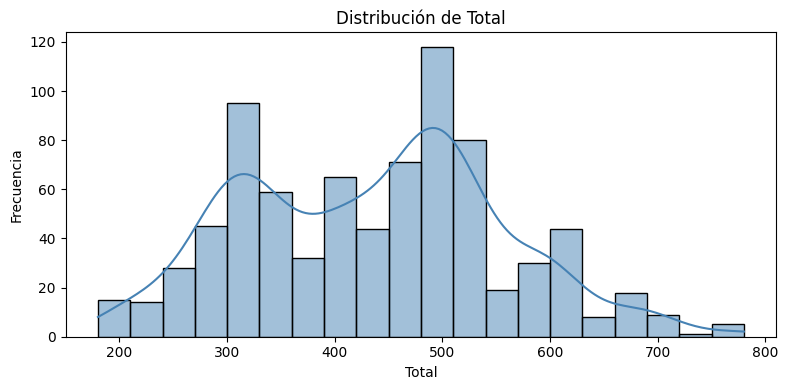

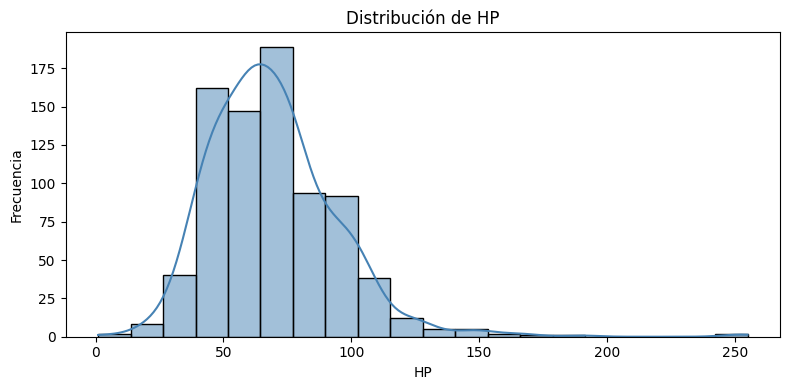

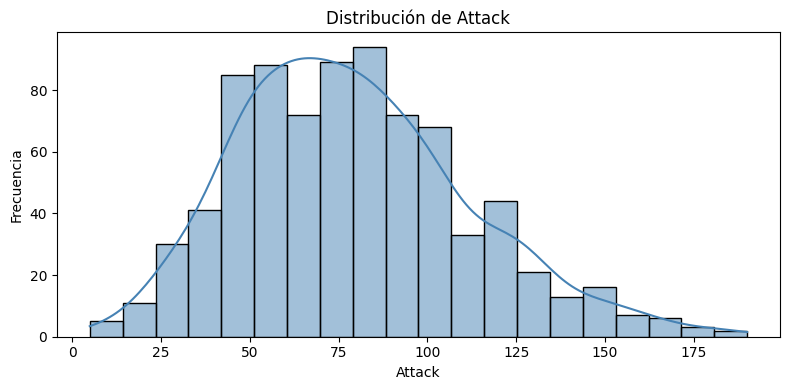

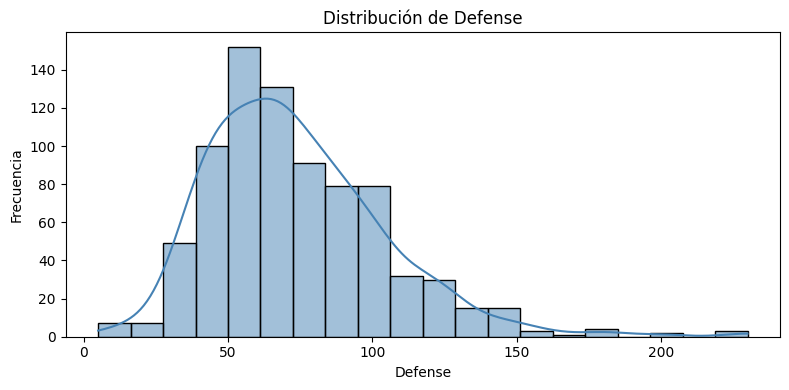

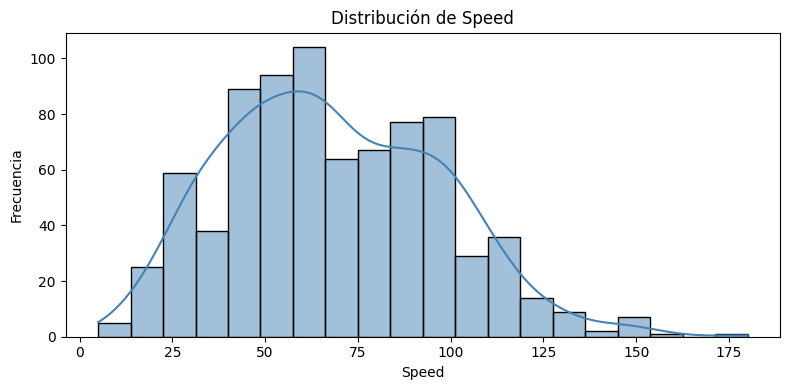

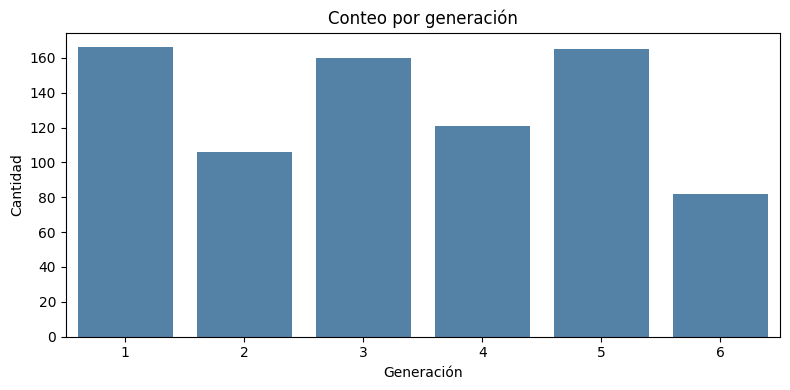

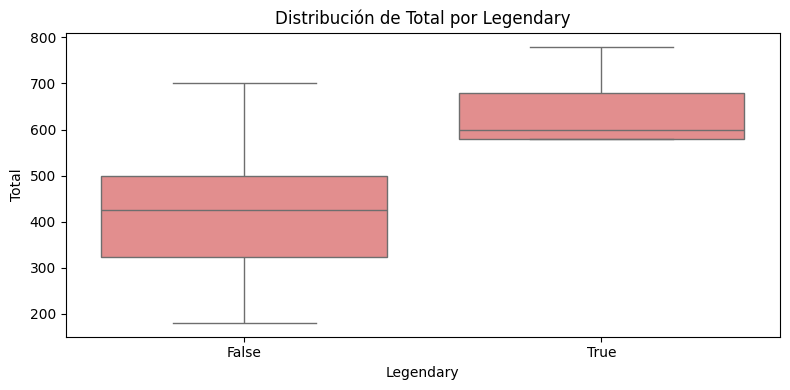

In [16]:
# Distribuciones y comparaciones visuales
for col in ['Total', 'HP', 'Attack', 'Defense', 'Speed']:
    if col in df.columns:
        plt.figure(figsize=(8, 4))
        sns.histplot(df[col], bins=20, kde=True, color='steelblue')
        plt.title(f'Distribución de {col}')
        plt.xlabel(col)
        plt.ylabel('Frecuencia')
        plt.tight_layout()
        plt.show()

if 'Generation' in df.columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x='Generation', color='steelblue')
    plt.title('Conteo por generación')
    plt.xlabel('Generación')
    plt.ylabel('Cantidad')
    plt.tight_layout()
    plt.show()

if 'Legendary' in df.columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x='Legendary', y='Total', color='lightcoral')
    plt.title('Distribución de Total por Legendary')
    plt.xlabel('Legendary')
    plt.ylabel('Total')
    plt.tight_layout()
    plt.show()

In [17]:
pip install "nbformat>=4.2.0"


Note: you may need to restart the kernel to use updated packages.


In [18]:
import pandas as pd
import plotly.express as px

# Carga del dataset para que la celda funcione incluso tras reiniciar el kernel
if 'df' not in globals():
    df = pd.read_excel('Dataset/Pokemon.xlsx')

# Gráficos interactivos para variables cuantitativas
quant_vars = ['Total', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
for col in quant_vars:
    if col in df.columns:
        fig = px.histogram(df, x=col, nbins=30, marginal='box', title=f'Distribución interactiva de {col}')
        fig.show()

# Gráfico interactivo de dispersión: Total vs Attack
fig = px.scatter(df, x='Attack', y='Total', color='Legendary', hover_data=['Name', 'Type 1', 'Generation'],
                 title='Total vs Attack (interactivo)')
fig.show()

# Gráfico interactivo de caja por tipo nominal
if 'Type 1' in df.columns:
    fig = px.box(df, x='Type 1', y='Total', color='Type 1', title='Total por Tipo Principal')
    fig.update_layout(xaxis={'categoryarray': sorted(df['Type 1'].unique())})
    fig.show()

# Gráfico interactivo de barras por generación
if 'Generation' in df.columns:
    gen_counts = df['Generation'].value_counts().reset_index()
    gen_counts.columns = ['Generation', 'Count']
    fig = px.bar(gen_counts, x='Generation', y='Count', color='Generation', text='Count',
                 title='Conteo de Pokémon por Generación')
    fig.show()

# Gráfico interactivo de pastel por Legendary
if 'Legendary' in df.columns:
    legend_counts = df['Legendary'].value_counts().reset_index()
    legend_counts.columns = ['Legendary', 'Count']
    fig = px.pie(legend_counts, names='Legendary', values='Count', title='Proporción de Legendary vs No Legendary')
    fig.show()

In [19]:
pip install ipywidgets

  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Note: you may need to restart the kernel to use updated packages.
